In [3]:
import pandas as pd

df = pd.read_csv("visa_applications_original.csv")

df.head()

,age,nationality,marital_status,education_level,destination_country,visa_type,duration_of_stay,monthly_income_usd,bank_balance_usd,prev_countries_visited,prev_visa_rejections,has_return_ticket,has_criminal_record,visa_approved
0,39,Canadian,Single,PhD,France,Tourist,110,9680,144968,15,5,0,0,0
1,41,Chinese,Divorced,High School,Australia,Student,69,11327,70594,7,0,0,0,1
2,61,Canadian,Divorced,High School,UK,Tourist,288,9397,159659,0,4,0,0,0
3,55,German,Divorced,PhD,France,Work,300,13453,137241,16,3,0,0,0
4,40,Indian,Divorced,Bachelors,Canada,Tourist,291,9682,171722,4,5,1,0,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     10000 non-null  int64 
 1   nationality             10000 non-null  object
 2   marital_status          10000 non-null  object
 3   education_level         10000 non-null  object
 4   destination_country     10000 non-null  object
 5   visa_type               10000 non-null  object
 6   duration_of_stay        10000 non-null  int64 
 7   monthly_income_usd      10000 non-null  int64 
 8   bank_balance_usd        10000 non-null  int64 
 9   prev_countries_visited  10000 non-null  int64 
 10  prev_visa_rejections    10000 non-null  int64 
 11  has_return_ticket       10000 non-null  int64 
 12  has_criminal_record     10000 non-null  int64 
 13  visa_approved           10000 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

age                       0
nationality               0
marital_status            0
education_level           0
destination_country       0
visa_type                 0
duration_of_stay          0
monthly_income_usd        0
bank_balance_usd          0
prev_countries_visited    0
prev_visa_rejections      0
has_return_ticket         0
has_criminal_record       0
visa_approved             0
dtype: int64

In [7]:
df['visa_approved'].value_counts()

visa_approved
0    5983
1    4017
Name: count, dtype: int64

In [8]:
df['nationality'].unique()

array(['Canadian', 'Chinese', 'German', 'Indian', 'American', 'Nigerian',
       'Australian', 'British'], dtype=object)

In [9]:
df['marital_status'].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

In [10]:
df['education_level'].unique()

array(['PhD', 'High School', 'Bachelors', 'Masters'], dtype=object)

In [11]:
df['destination_country'].unique()

array(['France', 'Australia', 'UK', 'Canada', 'Germany', 'USA'],
      dtype=object)

In [12]:
df['visa_type'].unique()

array(['Tourist', 'Student', 'Work'], dtype=object)

In [13]:
df['financial_ratio'] = df['bank_balance_usd'] / df['monthly_income_usd']

df['travel_history_score'] = df['prev_countries_visited'] - df['prev_visa_rejections']

df['risk_flag'] = df['has_criminal_record'] + df['prev_visa_rejections']

In [14]:
df.head()

,age,nationality,marital_status,education_level,destination_country,visa_type,duration_of_stay,monthly_income_usd,bank_balance_usd,prev_countries_visited,prev_visa_rejections,has_return_ticket,has_criminal_record,visa_approved,financial_ratio,travel_history_score,risk_flag
0,39,Canadian,Single,PhD,France,Tourist,110,9680,144968,15,5,0,0,0,14.976033,10,5
1,41,Chinese,Divorced,High School,Australia,Student,69,11327,70594,7,0,0,0,1,6.232365,7,0
2,61,Canadian,Divorced,High School,UK,Tourist,288,9397,159659,0,4,0,0,0,16.990422,-4,4
3,55,German,Divorced,PhD,France,Work,300,13453,137241,16,3,0,0,0,10.201516,13,3
4,40,Indian,Divorced,Bachelors,Canada,Tourist,291,9682,171722,4,5,1,0,0,17.736212,-1,5


In [15]:
df = pd.get_dummies(
    df,
    columns=[
        'nationality',
        'marital_status',
        'destination_country',
        'visa_type'
    ],
    drop_first=False
)

In [16]:
education_map = {
    "High School": 0,
    "Bachelors": 1,
    "Masters": 2,
    "PhD": 3
}

df["education_level"] = df["education_level"].map(education_map)

In [17]:
df.head()

,age,education_level,duration_of_stay,monthly_income_usd,bank_balance_usd,prev_countries_visited,prev_visa_rejections,has_return_ticket,has_criminal_record,visa_approved,...,marital_status_Single,destination_country_Australia,destination_country_Canada,destination_country_France,destination_country_Germany,destination_country_UK,destination_country_USA,visa_type_Student,visa_type_Tourist,visa_type_Work
0,39,3,110,9680,144968,15,5,0,0,0,...,True,False,False,True,False,False,False,False,True,False
1,41,0,69,11327,70594,7,0,0,0,1,...,False,True,False,False,False,False,False,True,False,False
2,61,0,288,9397,159659,0,4,0,0,0,...,False,False,False,False,False,True,False,False,True,False
3,55,3,300,13453,137241,16,3,0,0,0,...,False,False,False,True,False,False,False,False,False,True
4,40,1,291,9682,171722,4,5,1,0,0,...,False,False,True,False,False,False,False,False,True,False


In [18]:
df.columns

Index(['age', 'education_level', 'duration_of_stay', 'monthly_income_usd',
       'bank_balance_usd', 'prev_countries_visited', 'prev_visa_rejections',
       'has_return_ticket', 'has_criminal_record', 'visa_approved',
       'financial_ratio', 'travel_history_score', 'risk_flag',
       'nationality_American', 'nationality_Australian', 'nationality_British',
       'nationality_Canadian', 'nationality_Chinese', 'nationality_German',
       'nationality_Indian', 'nationality_Nigerian', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'destination_country_Australia', 'destination_country_Canada',
       'destination_country_France', 'destination_country_Germany',
       'destination_country_UK', 'destination_country_USA',
       'visa_type_Student', 'visa_type_Tourist', 'visa_type_Work'],
      dtype='object')

In [19]:
df.corr(numeric_only=True)['visa_approved'].sort_values(ascending=False)

visa_approved                    1.000000
travel_history_score             0.242231
bank_balance_usd                 0.115225
monthly_income_usd               0.106095
education_level                  0.095154
has_return_ticket                0.062859
prev_countries_visited           0.039692
visa_type_Student                0.019563
nationality_Chinese              0.017199
duration_of_stay                 0.013512
destination_country_France       0.009457
visa_type_Tourist                0.005542
destination_country_Australia    0.005104
nationality_Australian           0.004505
marital_status_Divorced          0.004037
nationality_American             0.003180
marital_status_Single            0.002258
nationality_German               0.001970
destination_country_Germany      0.001870
destination_country_USA          0.001749
nationality_British              0.000473
age                              0.000310
nationality_Nigerian            -0.000189
marital_status_Married          -0

In [20]:
df.to_csv("visa_feature_engineered_dataset.csv", index=False)

In [21]:
X = df.drop('visa_approved', axis=1)
y = df['visa_approved']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
print(X_train.columns)

Index(['age', 'education_level', 'duration_of_stay', 'monthly_income_usd',
       'bank_balance_usd', 'prev_countries_visited', 'prev_visa_rejections',
       'has_return_ticket', 'has_criminal_record', 'financial_ratio',
       'travel_history_score', 'risk_flag', 'nationality_American',
       'nationality_Australian', 'nationality_British', 'nationality_Canadian',
       'nationality_Chinese', 'nationality_German', 'nationality_Indian',
       'nationality_Nigerian', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'destination_country_Australia', 'destination_country_Canada',
       'destination_country_France', 'destination_country_Germany',
       'destination_country_UK', 'destination_country_USA',
       'visa_type_Student', 'visa_type_Tourist', 'visa_type_Work'],
      dtype='object')


In [25]:
y_pred = rf.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.913

Confusion Matrix:
[[1092   92]
 [  82  734]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1184
           1       0.89      0.90      0.89       816

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [27]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

risk_flag                 0.334843
prev_visa_rejections      0.284196
bank_balance_usd          0.055829
monthly_income_usd        0.046560
financial_ratio           0.042271
travel_history_score      0.039897
duration_of_stay          0.029365
age                       0.025824
prev_countries_visited    0.023294
education_level           0.022007
dtype: float64


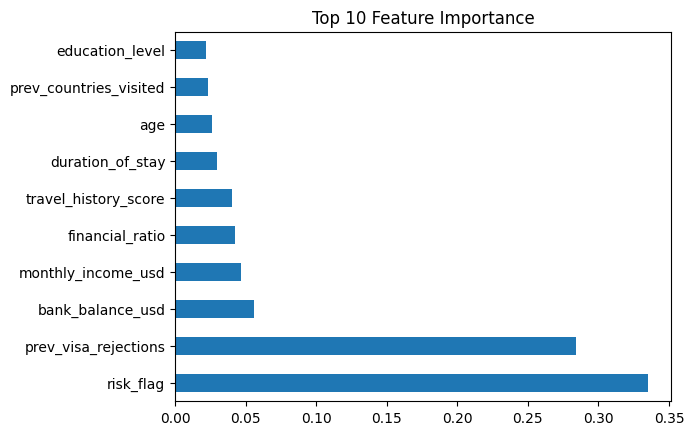

In [28]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.9135 0.917  0.918  0.9185 0.908 ]
Average Accuracy: 0.915


In [30]:
train_acc = rf.fit(X_train, y_train).score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.913


In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [32]:
from sklearn.metrics import accuracy_score

y_pred_train = rf.predict(X_train)

train_accuracy = accuracy_score(y_train, y_pred_train)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.954625


In [33]:
y_pred = rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9135


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1184
           1       0.88      0.91      0.90       816

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [35]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1084  100]
 [  73  743]]


In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.9135 0.916  0.9165 0.917  0.909 ]
Average Accuracy: 0.9144


In [37]:
import joblib

joblib.dump(rf, "visa_prediction_model.pkl")

['visa_prediction_model.pkl']

In [38]:
model = joblib.load("visa_prediction_model.pkl")

In [39]:
sample = X.iloc[0:1]

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Prediction:", prediction)
print("Approval Probability:", probability)

Prediction: [0]
Approval Probability: [[0.97861066 0.02138934]]


In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.896


c:\Users\Pavan A Kustagi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [200,300,400,500,600],
    "max_depth": [8,10,12,14,16,None],
    "min_samples_split": [2,5,10,15],
    "min_samples_leaf": [1,2,4,6],
    "max_features": ["sqrt","log2"],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [8, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [42]:
best_rf = random_search.best_estimator_

print("Best parameters:")
print(random_search.best_params_)

Best parameters:
{'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 12, 'bootstrap': False}


In [43]:
y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.912
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1184
           1       0.88      0.91      0.89       816

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [44]:
from sklearn.metrics import roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.973295906200318


In [45]:
import numpy as np

y_prob = best_rf.predict_proba(X_test)[:,1]

threshold = 0.6
y_pred_custom = (y_prob > threshold).astype(int)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_custom))

Accuracy: 0.9155


In [46]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

risk_flag                        0.405526
prev_visa_rejections             0.342189
bank_balance_usd                 0.045257
travel_history_score             0.035598
monthly_income_usd               0.032817
financial_ratio                  0.029099
education_level                  0.019334
prev_countries_visited           0.014494
has_criminal_record              0.013882
duration_of_stay                 0.013852
age                              0.012133
has_return_ticket                0.007156
marital_status_Single            0.001878
visa_type_Tourist                0.001839
nationality_Chinese              0.001793
marital_status_Divorced          0.001785
marital_status_Married           0.001760
visa_type_Student                0.001720
visa_type_Work                   0.001695
destination_country_Canada       0.001550
destination_country_USA          0.001517
destination_country_France       0.001479
nationality_Indian               0.001280
nationality_American             0

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        max_depth=12,
        min_samples_leaf=2,
        max_features="log2",
        bootstrap=False,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "Extra Trees": ExtraTreesClassifier(n_estimators=400),

    "XGBoost": XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

In [49]:
from sklearn.model_selection import cross_val_score
import pandas as pd

results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std": scores.std()
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Mean ROC-AUC", ascending=False))

                 Model  Mean ROC-AUC       Std
2    Gradient Boosting      0.977641  0.004192
4              XGBoost      0.975004  0.003774
1        Random Forest      0.974548  0.004578
3          Extra Trees      0.969815  0.004955
0  Logistic Regression      0.967135  0.005225


In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [51]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.9115
ROC AUC: 0.9736726616322204
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1184
           1       0.89      0.89      0.89       816

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [52]:
import pandas as pd

importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(15))

risk_flag                     0.779308
bank_balance_usd              0.080259
monthly_income_usd            0.045629
education_level               0.028863
financial_ratio               0.011544
duration_of_stay              0.008241
has_return_ticket             0.008003
travel_history_score          0.007213
has_criminal_record           0.007169
age                           0.005169
prev_countries_visited        0.004719
prev_visa_rejections          0.004500
nationality_Chinese           0.001098
visa_type_Tourist             0.000848
destination_country_France    0.000642
dtype: float64


In [53]:
df['visa_approved'].value_counts()

visa_approved
0    5983
1    4017
Name: count, dtype: int64

In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("visa_feature_engineered_dataset.csv")